In [2]:
!pip install pandas matplotlib seaborn ipykernel --quiet

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything imported successfully")

ModuleNotFoundError: No module named 'seaborn'

In [4]:
!pip install seaborn

In [5]:
import seaborn as sns

print("Seaborn installed!")

ModuleNotFoundError: No module named 'seaborn'

In [6]:
import sys
!{sys.executable} -m pip install seaborn

'C:\Users\eyobg\Desktop\Internship' is not recognized as an internal or external command,
operable program or batch file.


In [7]:
import sys
print(sys.executable)

C:\Users\eyobg\Desktop\Internship Training\notebook\week1\Scripts\python.exe


In [8]:
import os
print(os.getcwd())

C:\Users\eyobg\Desktop\Internship Training\notebook\week1-slack-analysis\notebooks


In [9]:
import sys
!"{sys.executable}" -m pip install seaborn

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything works!")

Everything works!


In [2]:
import json
import os
import pprint

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime

# Plot style
plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

# Path to the dataset
DATA_PATH = '../data'

print('Data path exists:', os.path.exists(DATA_PATH))
print('Available channels:', os.listdir(DATA_PATH)[:5], '...')

Data path exists: True
Available channels: ['ab_test-group', 'adludios-challange', 'all-broadcast', 'all-career-exercises', 'all-community-building'] ...


In [3]:
def load_channel(data_path, channel_name):
    """Load all messages from a single channel into a list of dicts."""
    channel_path = os.path.join(data_path, channel_name)
    all_messages = []

    for filename in sorted(os.listdir(channel_path)):
        if filename.endswith('.json'):
            filepath = os.path.join(channel_path, filename)
            with open(filepath, encoding='utf-8') as f:
                messages = json.load(f)
                for msg in messages:
                    msg['channel'] = channel_name
                    msg['date'] = filename.replace('.json', '')
                all_messages.extend(messages)

    return all_messages


# Load one channel to start
sample_channel = 'all-broadcast'
messages = load_channel(DATA_PATH, sample_channel)
print(f'Total messages in "{sample_channel}": {len(messages)}')

Total messages in "all-broadcast": 559


In [4]:
# Inspect one raw message - look at every field carefully
pprint.pprint(messages[5])

print('\n--- Key fields to remember ---')
print('ts           : Unix timestamp (seconds since 1970)')
print('user         : User ID who sent the emssage')
print('text         : Message content')
print('reply_count  : Number of replies')
print('replies      : List of {user, ts} dicts for each reply')
print('reations     : List of {name, count, users} dicts')

{'attachments': None,
 'blocks': [{'block_id': 'X4T4q',
             'elements': [{'elements': [{'text': 'if you are not able to view '
                                                 'the folder - first review if '
                                                 'you are viewing with the '
                                                 'right email. if not, switch '
                                                 'to the right email instead '
                                                 'of sending access requests.',
                                         'type': 'text'}],
                           'type': 'rich_text_section'}],
             'type': 'rich_text'}],
 'channel': 'all-broadcast',
 'client_msg_id': '58e5790b-ab05-4f4f-9edc-bf223b7b8af1',
 'date': '2022-08-21',
 'source_team': 'T03U4J8HMUG',
 'team': 'T03U4J8HMUG',
 'text': 'if you are not able to view the folder - first review if you are '
         'viewing with the right email. if not, switch to the right emai

In [5]:
# Convert list of dicts to a DataFrame
df = pd.json_normalize(messages)
print('Shape:', df.shape)
print('\nAll columns:')
print(df.columns.tolist())
df.head()

Shape: (559, 38)

All columns:
['type', 'subtype', 'ts', 'user', 'text', 'blocks', 'attachments', 'channel', 'date', 'client_msg_id', 'team', 'user_team', 'source_team', 'user_profile.avatar_hash', 'user_profile.image_72', 'user_profile.first_name', 'user_profile.real_name', 'user_profile.display_name', 'user_profile.team', 'user_profile.name', 'user_profile.is_restricted', 'user_profile.is_ultra_restricted', 'reactions', 'edited.user', 'edited.ts', 'thread_ts', 'reply_count', 'reply_users_count', 'latest_reply', 'reply_users', 'replies', 'is_locked', 'subscribed', 'last_read', 'parent_user_id', 'files', 'upload', 'display_as_bot']


,type,subtype,ts,user,text,blocks,attachments,channel,date,client_msg_id,...,latest_reply,reply_users,replies,is_locked,subscribed,last_read,parent_user_id,files,upload,display_as_bot
0,message,channel_join,1660300985.527899,U03TEPYRM2P,<@u03tepyrm2p> has joined the channel,None,None,all-broadcast,2022-08-12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,message,channel_posting_permissions,1660301251.687329,U03TEPYRM2P,changed channel posting permissions,None,None,all-broadcast,2022-08-12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,message,channel_join,1660301593.419249,U03T89ACUUW,<@u03t89acuuw> has joined the channel,None,None,all-broadcast,2022-08-12,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,message,NaN,1661143290.593769,U03T89ACUUW,hi all - note that you have been shared a week...,"[{'type': 'rich_text', 'block_id': 'gMZv', 'el...",None,all-broadcast,2022-08-21,7ad7deef-a83c-4c98-8677-5a551a36fced,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,message,NaN,1661143383.691609,U03T89ACUUW,note: ensure that you are logged in with the e...,"[{'type': 'rich_text', 'block_id': 'PVO+', 'el...",None,all-broadcast,2022-08-21,66386e36-ae7c-4596-a902-e5c54b842f73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Convert Unix timestamp to a readable datetime
df['datetime'] = pd.to_datetime(df['ts'].astype(float), unit='s')
df['hour'] = df['datetime'].dt.hour

# Fill missing reply columns with 0
df['reply_count'] = df['reply_count'].fillna(0).astype(int)
df['reply_users_count'] = df['reply_users_count'].fillna(0).astype(int)

print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
df[['datetime', 'user', 'text', 'reply_count']].head()

Date range: 2022-08-12 10:43:05.527899027 to 2022-12-12 07:35:26.080769062


,datetime,user,text,reply_count
0,2022-08-12 10:43:05.527899027,U03TEPYRM2P,<@u03tepyrm2p> has joined the channel,0
1,2022-08-12 10:47:31.687329054,U03TEPYRM2P,changed channel posting permissions,0
2,2022-08-12 10:53:13.419249058,U03T89ACUUW,<@u03t89acuuw> has joined the channel,0
3,2022-08-22 04:41:30.593769073,U03T89ACUUW,hi all - note that you have been shared a week...,0
4,2022-08-22 04:43:03.691608906,U03T89ACUUW,note: ensure that you are logged in with the e...,0


In [7]:
def load_all_channels(data_path):
    """Load messages from every channel into one DataFrame."""
    all_messages = []

    for channel in sorted(os.listdir(data_path)):
        channel_path = os.path.join(data_path, channel)
        if os.path.isdir(channel_path):
            msgs = load_channel(data_path, channel)
            all_messages.extend(msgs)
            print(f'  Loaded {channel}: {len(msgs)} messages')

    df = pd.json_normalize(all_messages)
    df['datetime'] = pd.to_datetime(df['ts'].astype(float), unit='s')
    df['hour'] = df['datetime'].dt.hour
    df['reply_count'] = df.get('reply_count', pd.Series(0, index=df.index)).fillna(0).astype(int)
    df['reply_users_count'] = df.get('reply_users_count', pd.Series(0, index=df.index)).fillna(0).astype(int)

    return df

print('Loading all channels...')
df_all = load_all_channels(DATA_PATH)
print(f'\nTotal messages : {len(df_all)}')
print(f'Unique channels: {df_all["channel"].nunique()}')
print(f'Unique users   : {df_all["user"].nunique()}')

Loading all channels...
  Loaded ab_test-group: 573 messages
  Loaded adludios-challange: 611 messages
  Loaded all-broadcast: 559 messages
  Loaded all-career-exercises: 828 messages
  Loaded all-community-building: 8302 messages
  Loaded all-de-week12: 25 messages
  Loaded all-ideas: 285 messages
  Loaded all-ml-week12: 19 messages
  Loaded all-resources: 1506 messages
  Loaded all-technical-support: 161 messages
  Loaded all-web3-week12: 9 messages
  Loaded all-week1: 596 messages
  Loaded all-week10: 224 messages
  Loaded all-week11: 291 messages
  Loaded all-week12: 125 messages
  Loaded all-week2: 350 messages
  Loaded all-week3: 482 messages
  Loaded all-week4: 371 messages
  Loaded all-week5: 536 messages
  Loaded all-week6: 385 messages
  Loaded all-week7: 555 messages
  Loaded all-week8: 137 messages
  Loaded all-week9: 178 messages
  Loaded anonymized: 0 messages
  Loaded batch6_week4_studygroup: 6 messages
  Loaded chang-w11: 108 messages
  Loaded data-engineering: 39 messa

In [8]:
import re
import numpy as np

# Helper functions 

def count_mentions(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r"<@[A-Z0-9]+>", text, flags=re.IGNORECASE))


def count_reactions(reactions):
    if not isinstance(reactions, list):
        return 0
    return sum(r.get("count", 0) for r in reactions if isinstance(r, dict))


def first_reply_ts(replies):
    if not isinstance(replies, list) or len(replies) == 0:
        return np.nan

    timestamps = []
    for reply in replies:
        if isinstance(reply, dict) and reply.get("ts") is not None:
            timestamps.append(float(reply.get("ts")))

    return min(timestamps) if timestamps else np.nan


# Add useful EDA columns

df_all["mention_count"] = df_all["text"].apply(count_mentions)
df_all["reaction_count"] = df_all["reactions"].apply(count_reactions) if "reactions" in df_all.columns else 0

if "replies" in df_all.columns:
    df_all["first_reply_ts"] = df_all["replies"].apply(first_reply_ts)
else:
    df_all["first_reply_ts"] = np.nan

df_all["first_reply_datetime"] = pd.to_datetime(df_all["first_reply_ts"], unit="s", errors="coerce")
df_all["reply_time_minutes"] = (
    df_all["first_reply_datetime"] - df_all["datetime"]
).dt.total_seconds() / 60

df_all[["user", "channel", "text", "reply_count", "mention_count", "reaction_count"]].head()

,user,channel,text,reply_count,mention_count,reaction_count
0,U03U9FWPNCE,ab_test-group,<@u03u9fwpnce> has joined the channel,0,1,0
1,U03UD4FEDHB,ab_test-group,<@u03ud4fedhb> has joined the channel,0,1,0
2,U03U1HAG9TR,ab_test-group,<@u03u1hag9tr> has joined the channel,0,1,0
3,U03UG4Q7V42,ab_test-group,<@u03ug4q7v42> has joined the channel,0,1,0
4,U03U9FWPNCE,ab_test-group,"hi guys,\ni thought having a group chat would ...",0,2,0


In [9]:
user_stats = df_all.groupby("user").agg(
    message_count=("user", "size"),
    reply_count=("reply_count", "sum"),
    mention_count=("mention_count", "sum"),
    reaction_count=("reaction_count", "sum")
).sort_values("message_count", ascending=False)

for col in ["message_count", "reply_count", "mention_count", "reaction_count"]:
    print(f"\nTop 10 users by {col}:")
    print(user_stats.sort_values(col, ascending=False).head(10))

    print(f"\nBottom 10 users by {col}:")
    print(user_stats.sort_values(col, ascending=True).head(10))


Top 10 users by message_count:
             message_count  reply_count  mention_count  reaction_count
user                                                                  
U03V1AM5TFA           1554          614            633            1124
U03UUR571A5           1206          414            178             573
U03UVHCV6KB           1178          435            205             440
U03UG32J3PC           1070          363            241             625
U03UH397319            910          453            165             125
U03V6HMRPGQ            902          727            228             509
U03UG4Q7V42            803          273            176             428
U03UD68RQH3            706          341            206             448
U03UJGP0C68            675          378            176             536
U03U1FNPEUX            575          308             88             360

Bottom 10 users by message_count:
             message_count  reply_count  mention_count  reaction_count
user      

In [25]:
# Count messages per user
msg_counts = df_all.groupby('user').size().rename('message_count')

# Sum replies received per user
reply_counts = df_all.groupby('user')['reply_count'].sum().rename('total_replies')

user_stats = pd.concat([msg_counts, reply_counts], axis=1).fillna(0)
user_stats = user_stats.sort_values('message_count', ascending=False)

print('Top 10 users by message count:')
print(user_stats.head(10))
print('\nBottom 10 users by message count:')
print(user_stats.tail(10))

Top 10 users by message count:
             message_count  total_replies
user                                     
U03V1AM5TFA           1554            614
U03UUR571A5           1206            414
U03UVHCV6KB           1178            435
U03UG32J3PC           1070            363
U03UH397319            910            453
U03V6HMRPGQ            902            727
U03UG4Q7V42            803            273
U03UD68RQH3            706            341
U03UJGP0C68            675            378
U03U1FNPEUX            575            308

Bottom 10 users by message count:
             message_count  total_replies
user                                     
U03UDKKESB1             13              0
USLACKBOT                9             15
U03UG03HQ2F              7              4
U03UH760JQK              6              0
U03UCCRJME2              5              0
U03UFT20ZJR              4              0
U03UK9CB71A              4              0
U03UR2LQ4DR              3              0
U04718Y7SQ

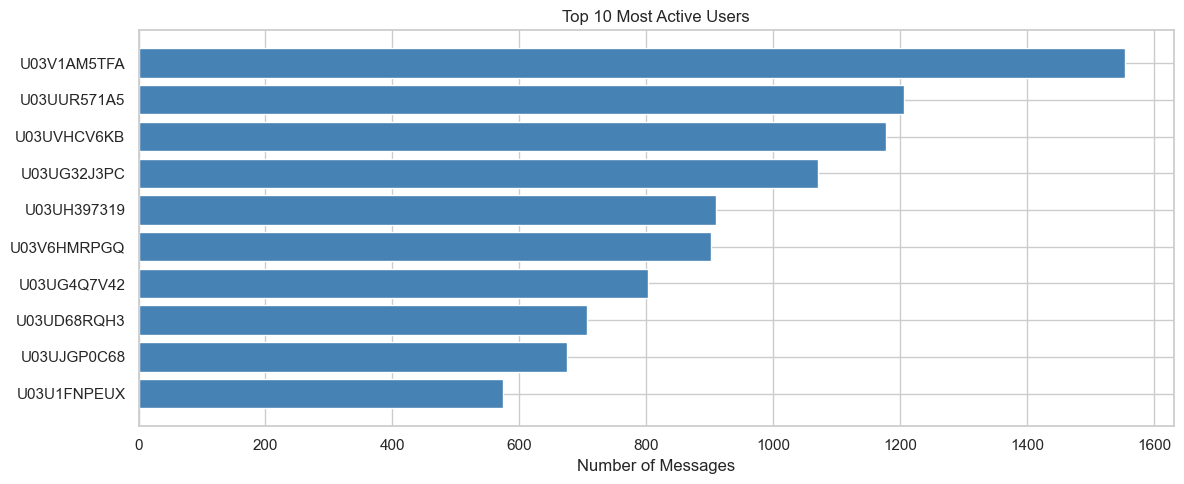

In [26]:
# Horizontal bar chart - top 10 most active users
top10 = user_stats.head(10)

fig, ax = plt.subplots()
ax.barh(top10.index, top10['message_count'], color='steelblue')
ax.set_xlabel('Number of Messages')
ax.set_title('Top 10 Most Active Users')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

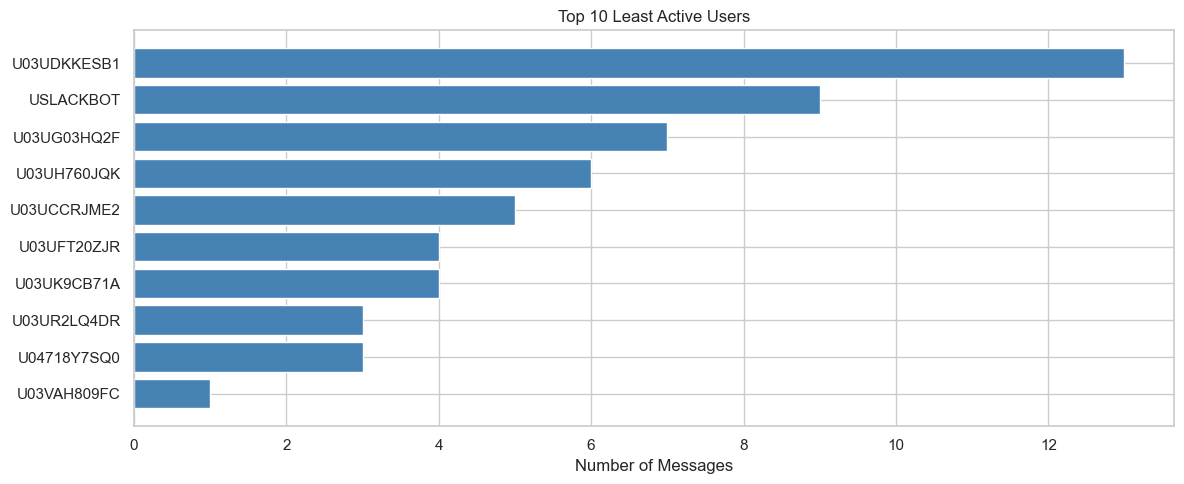

In [27]:
# Horizontal bar chart - top 10 least active users
top10 = user_stats.tail(10)

fig, ax = plt.subplots()
ax.barh(top10.index, top10['message_count'], color='steelblue')
ax.set_xlabel('Number of Messages')
ax.set_title('Top 10 Least Active Users')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Channel with highest total activity:


,messages,replies,reactions,replies_plus_reactions,total_activity
channel,,,,,
all-community-building,8302,3894,7043,10937,19239
all-career-exercises,828,475,589,1064,1892
all-resources,1506,89,249,338,1844
random,715,429,555,984,1699
kafka_de,958,390,54,444,1402
all-week1,596,426,113,539,1135
all-broadcast,559,186,327,513,1072
all-week7,555,361,148,509,1064
all-week5,536,395,88,483,1019


Channel appearing closest to the top-right corner:


,messages,replies,reactions,replies_plus_reactions,total_activity
channel,,,,,
all-community-building,8302,3894,7043,10937,19239


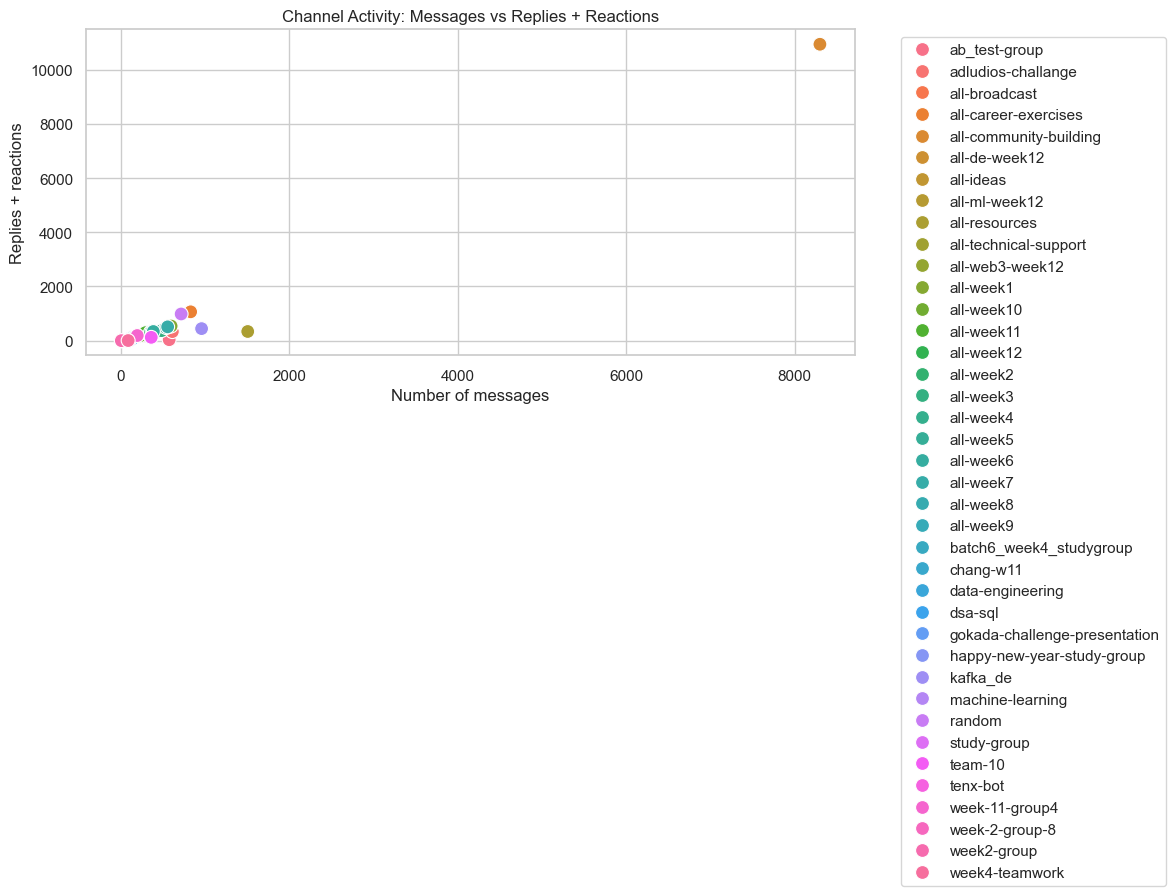

In [10]:
channel_stats = df_all.groupby("channel").agg(
    messages=("channel", "size"),
    replies=("reply_count", "sum"),
    reactions=("reaction_count", "sum")
)

channel_stats["replies_plus_reactions"] = channel_stats["replies"] + channel_stats["reactions"]
channel_stats["total_activity"] = channel_stats["messages"] + channel_stats["replies_plus_reactions"]

print("Channel with highest total activity:")
display(channel_stats.sort_values("total_activity", ascending=False).head(10))

top_right_channel = channel_stats.sort_values(
    ["messages", "replies_plus_reactions"],
    ascending=False
).head(1)

print("Channel appearing closest to the top-right corner:")
display(top_right_channel)

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=channel_stats.reset_index(),
    x="messages",
    y="replies_plus_reactions",
    hue="channel",
    s=100
)

plt.title("Channel Activity: Messages vs Replies + Reactions")
plt.xlabel("Number of messages")
plt.ylabel("Replies + reactions")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
replied_messages = df_all[df_all["reply_time_minutes"].notna()].copy()

within_5 = replied_messages[replied_messages["reply_time_minutes"] <= 5]

fraction_within_5 = len(within_5) / len(replied_messages) if len(replied_messages) > 0 else 0

print(f"Messages with replies: {len(replied_messages)}")
print(f"Messages replied within 5 minutes: {len(within_5)}")
print(f"Fraction replied within 5 minutes: {fraction_within_5:.2%}")

Messages with replies: 2027
Messages replied within 5 minutes: 1356
Fraction replied within 5 minutes: 66.90%


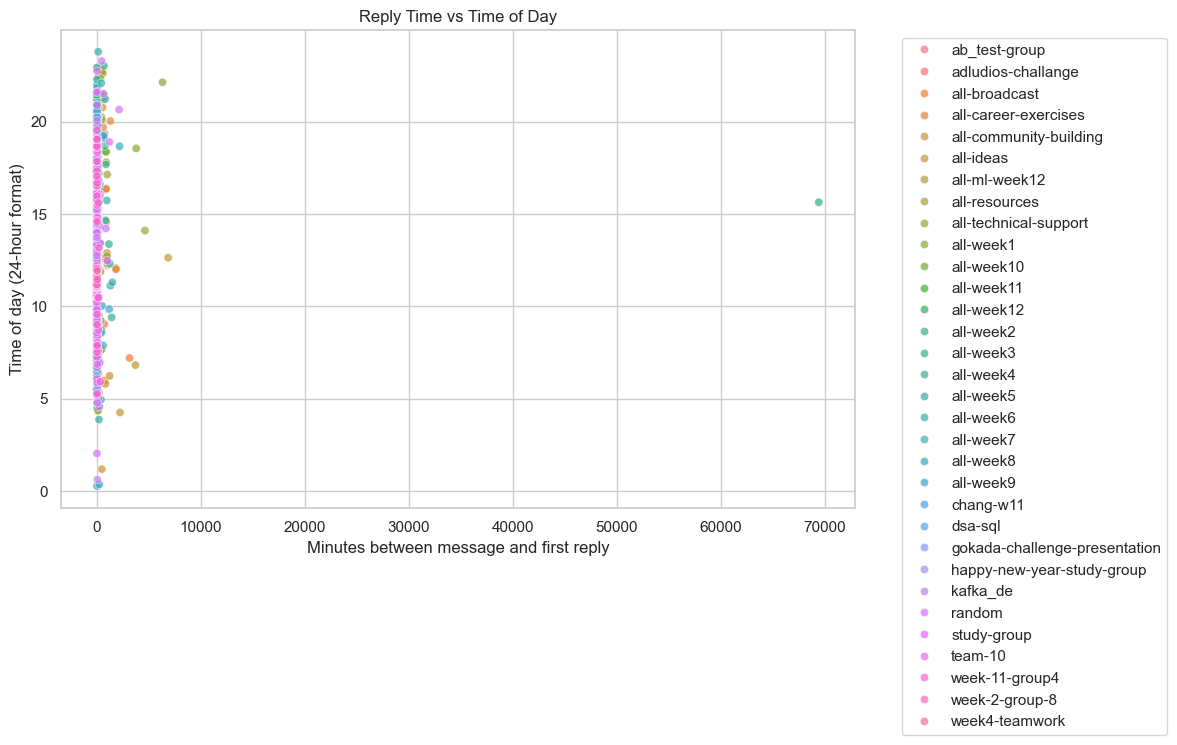

In [12]:
plot_df = df_all[
    df_all["reply_time_minutes"].notna()
    & (df_all["reply_time_minutes"] >= 0)
].copy()

plot_df["time_of_day"] = plot_df["datetime"].dt.hour + plot_df["datetime"].dt.minute / 60

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x="reply_time_minutes",
    y="time_of_day",
    hue="channel",
    alpha=0.7
)

plt.title("Reply Time vs Time of Day")
plt.xlabel("Minutes between message and first reply")
plt.ylabel("Time of day (24-hour format)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()